In [22]:
import jax
import jax.numpy as jnp
from jax import grad, vmap
import optax
import matplotlib.pyplot as plt

In [23]:
class FCN:
    @staticmethod
    def init_parameters(key, layer_sizes):
        keys = jax.random.split(key, len(layer_sizes)-1)
        parameters = [FCN._random_layer_parameters(k, m, n)
                      for k, m, n in zip(keys, layer_sizes[:-1], layer_sizes[1:])]
        return parameters

    @staticmethod
    def _random_layer_parameters(key, m, n):
        W_key, b_key = jax.random.split(key)
        v = jnp.sqrt(1/m)
        W = jax.random.uniform(W_key, (n, m), minval=-v, maxval=v)
        b = jax.random.uniform(b_key, (n,), minval=-v, maxval=v)
        return W, b

    @staticmethod
    def forward(parameters, x):
        activation_fn = jnp.tanh
        for W, b in parameters[:-1]:
            x = activation_fn(jnp.dot(W, x) + b)
        W_last, b_last = parameters[-1]
        y = jnp.dot(W_last, x) + b_last
        return y

In [24]:
def PINN_physics_loss(parameters, t, network):

    uv = network.forward(parameters, t)
    u = uv[0]
    v = uv[1]

    du_dt = jax.grad(lambda tt: network.forward(parameters, tt)[0])(t)
    dv_dt = jax.grad(lambda tt: network.forward(parameters, tt)[1])(t)

    r1 = du_dt + 4*u + 2*(u/(u+v))-3
    r2 = dv_dt + 3*v - 2*(u/(u+v))-2

    return r1**2 + r2**2


def PINN_boundary_losses(parameters, x_boundary, network):

    uv0 = network.forward(parameters, x_boundary)

    loss_u0 = (uv0[0] - 0.5) ** 2
    loss_v0 = (uv0[1] - 0.3) ** 2

    return loss_u0, loss_v0


def PINN_loss_batch(parameters, x_boundary, x_physics_batch, network):

    loss_physics_batch = jax.vmap(PINN_physics_loss, in_axes=(None, 0, None))(parameters, x_physics_batch, network)
    loss_physics = jnp.mean(loss_physics_batch)
    loss_u0, loss_v0 = PINN_boundary_losses(parameters, x_boundary, network)

    return 1e-4 * loss_physics + loss_u0 + loss_v0


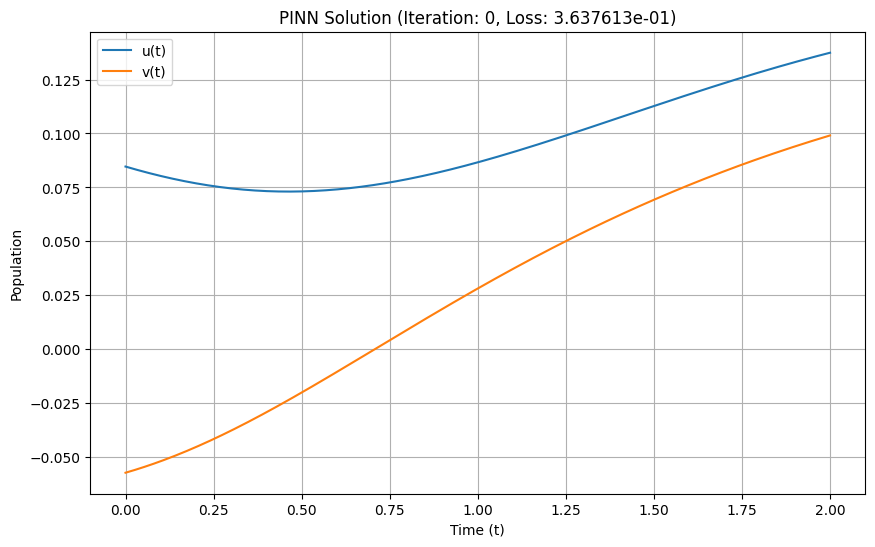

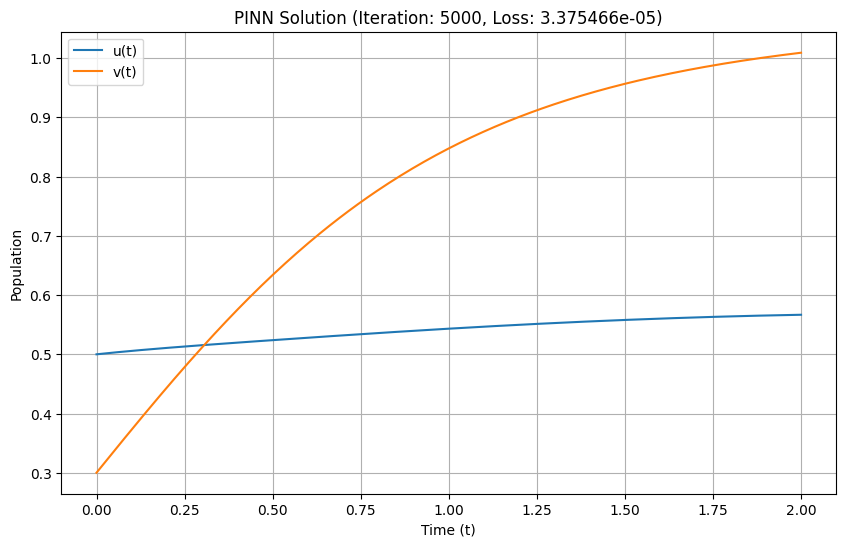

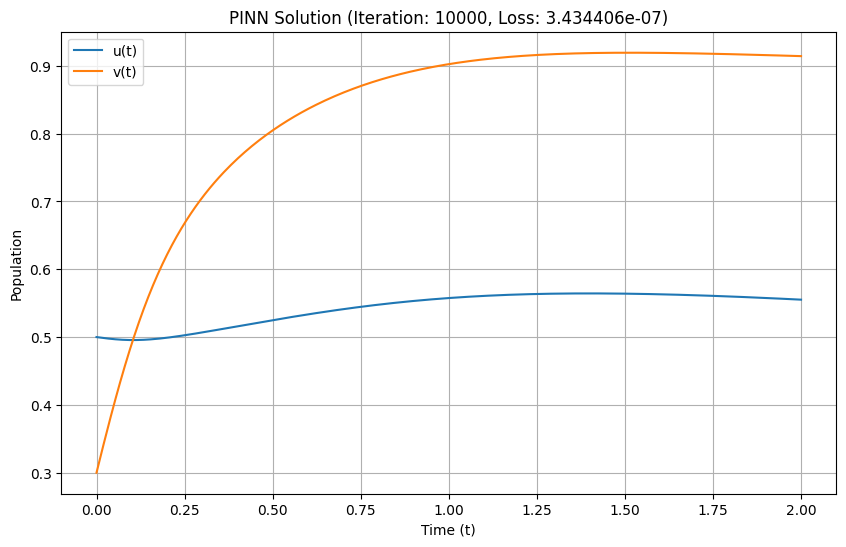

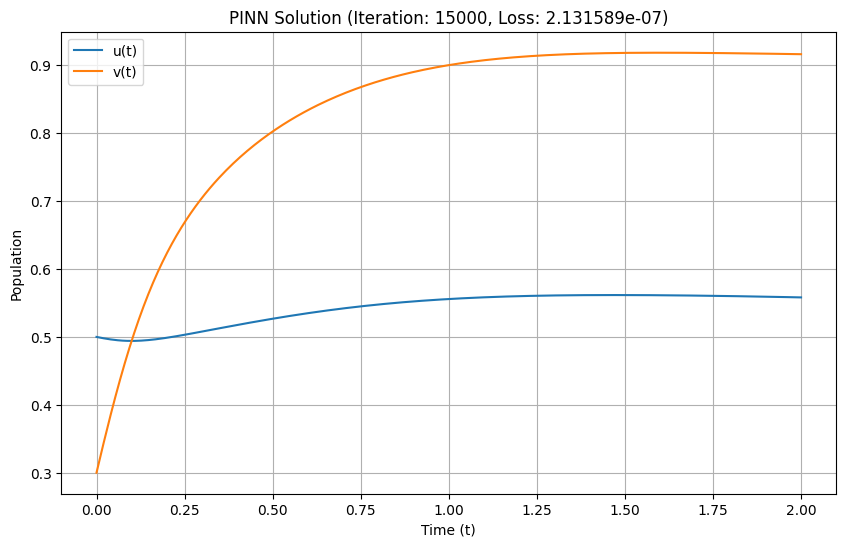

Forward PINN training loop finished in 6.31 seconds


In [25]:
import time # Import time module
from functools import partial

@partial(jax.jit, static_argnums=(1, 5))
def PINN_step(opt_state, optimiser, parameters, x_boundary, x_physics_batch, network):

    loss, grads = jax.value_and_grad(PINN_loss_batch, argnums=0)(
        parameters, x_boundary, x_physics_batch, network
    )

    updates, opt_state = optimiser.update(grads, opt_state, parameters)
    parameters = optax.apply_updates(parameters, updates)

    return loss, opt_state, parameters

x_boundary = jnp.array([0.0])
x_physics_batch = jnp.linspace(0, 2, 50).reshape(-1, 1)  #jnp.linspace(0, 50, 500).reshape(-1, 1)
x_test_batch = jnp.linspace(0, 2, 300).reshape(-1, 1)   #jnp.linspace(0, 50, 3000).reshape(-1, 1)

network = FCN

# Initialize a JAX random key
key = jax.random.PRNGKey(0)
parameters = network.init_parameters(key, [1, 32, 32, 2])

# Initialize the optimizer and its state
optimiser = optax.adam(learning_rate=1e-3)
opt_state = optimiser.init(parameters)

start_time_forward = time.time() # Record start time
for i in range(15001):
    loss, opt_state, parameters = PINN_step(
        opt_state,optimiser,parameters,x_boundary,x_physics_batch,network)

    if i % 5000 == 0:
        uv_test_batch = jax.vmap(network.forward, in_axes=(None, 0))(parameters, x_test_batch)

        plt.figure(figsize=(10, 6))
        plt.plot(x_test_batch, uv_test_batch[:, 0], label='u(t)')
        plt.plot(x_test_batch, uv_test_batch[:, 1], label='v(t)')
        plt.xlabel('Time (t)')
        plt.ylabel('Population')
        plt.title(f'PINN Solution (Iteration: {i}, Loss: {loss:.6e})')
        plt.legend()
        plt.grid(True)
        plt.show()

end_time_forward = time.time() # Record end time
print(f"Forward PINN training loop finished in {end_time_forward - start_time_forward:.2f} seconds")

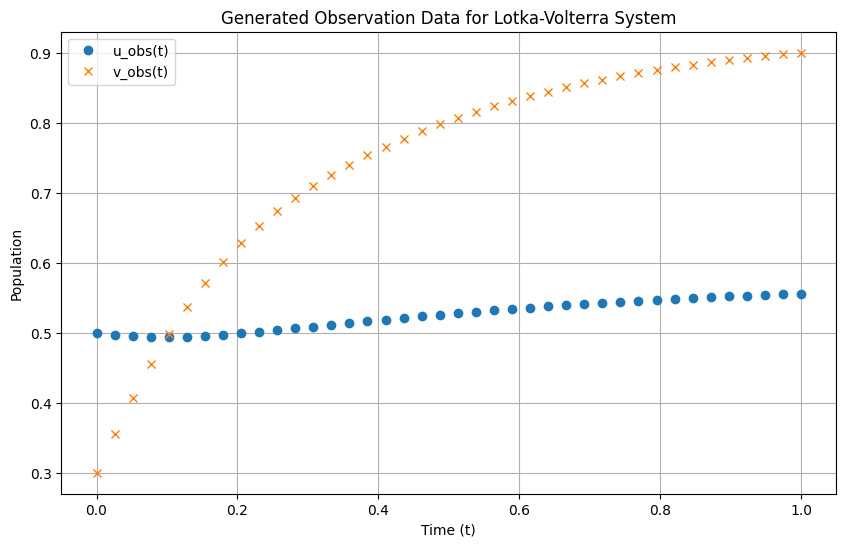

In [26]:
# Generate obs data using forward pinn

t_obs = jnp.linspace(0, 1, 40).reshape(-1, 1)
uv_obs = jax.vmap(network.forward, in_axes=(None, 0))(parameters, t_obs)

# Plot the generated observation data
plt.figure(figsize=(10, 6))
plt.plot(t_obs, uv_obs[:, 0], 'o', label='u_obs(t)')
plt.plot(t_obs, uv_obs[:, 1], 'x', label='v_obs(t)')
plt.xlabel('Time (t)')
plt.ylabel('Population')
plt.title('Generated Observation Data for Lotka-Volterra System')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
def PINN_inverse_physics_loss(parameters, theta, t, network):

    uv = network.forward(parameters, t)
    u = uv[0]
    v = uv[1]

    a = theta[0]
    b = theta[1]
    c = theta[2]

    du_dt = jax.grad(lambda tt: network.forward(parameters, tt)[0])(t)
    dv_dt = jax.grad(lambda tt: network.forward(parameters, tt)[1])(t)

    r1 = du_dt + a*u + b*(u/(u+v))-3
    r2 = dv_dt + c*v - b*(u/(u+v))-2

    return r1**2 + r2**2

def PINN_inverse_loss_batch(parameters, theta, x_physics_batch, network):

    physics_losses = jax.vmap(PINN_inverse_physics_loss, in_axes=(None, None, 0, None))(parameters, theta, x_physics_batch, network)
    loss_physics = jnp.mean(physics_losses)

    uv_pred = jax.vmap(network.forward, in_axes=(None, 0))(parameters, t_obs)
    loss_data = jnp.mean((uv_pred - uv_obs)**2)

    return 1e-4 * loss_physics + loss_data


In [28]:
# JIT-compiled Step Function
@partial(jax.jit, static_argnums=(1, 5))
def inverse_step(opt_state, optimiser, parameters, theta, x_physics_batch, network):

    # get loss and gradient over the combined parameters (network weights + alpha)
    loss, grads = jax.value_and_grad(PINN_inverse_loss_batch, argnums=(0, 1))(parameters, theta, x_physics_batch, network)
    grads_params, grads_theta = grads

    # apply parameter update
    updates, opt_state = optimiser.update((grads_params, grads_theta), opt_state,(parameters, theta))
    parameters, theta = optax.apply_updates((parameters, theta), updates)

    return loss, opt_state, parameters, theta

In [29]:
# Initialize and Run Training
parameters_inv = network.init_parameters(key, [1, 32, 32, 2])
theta_inv = jnp.array([3.0, 1.0, 2.0])

optimiser_inv = optax.adam(1e-3)
opt_state_inv = optimiser_inv.init((parameters_inv, theta_inv))

x_physics_batch = jnp.linspace(0, 2, 500).reshape(-1, 1)

iter: 0 loss: 1.135767 a: 3.0009987 b: 0.999


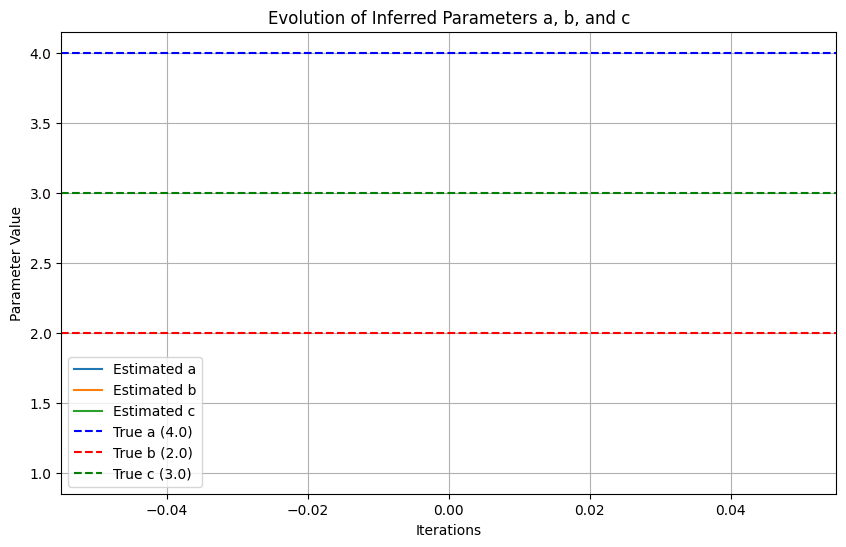

iter: 2000 loss: 0.15782806 a: 4.879538 b: 0.9931233


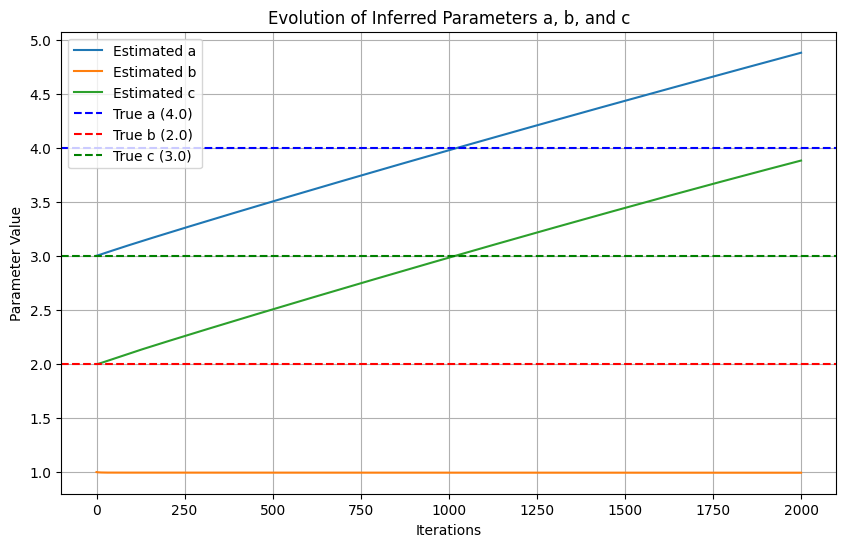

iter: 4000 loss: 0.079080015 a: 6.519196 b: 0.9993829


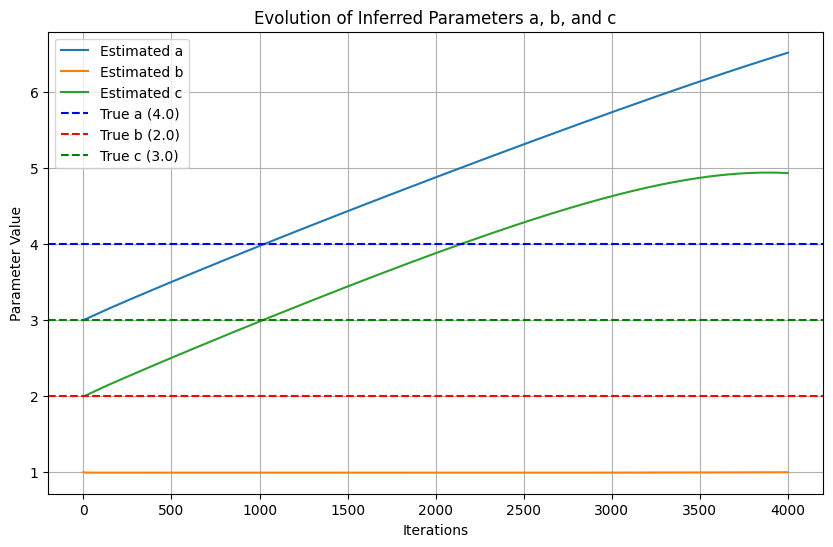

iter: 6000 loss: 0.0111281695 a: 6.5486546 b: 1.0079389


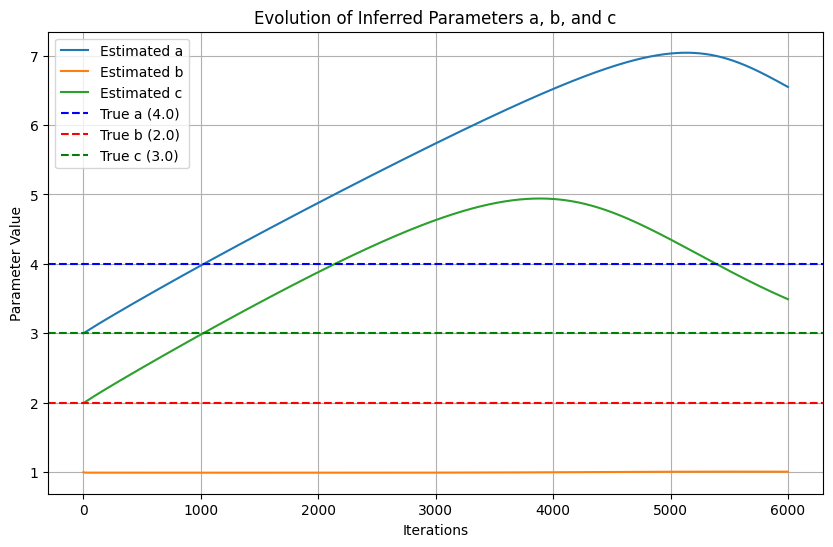

iter: 8000 loss: 0.0032418033 a: 5.2927184 b: 0.99389946


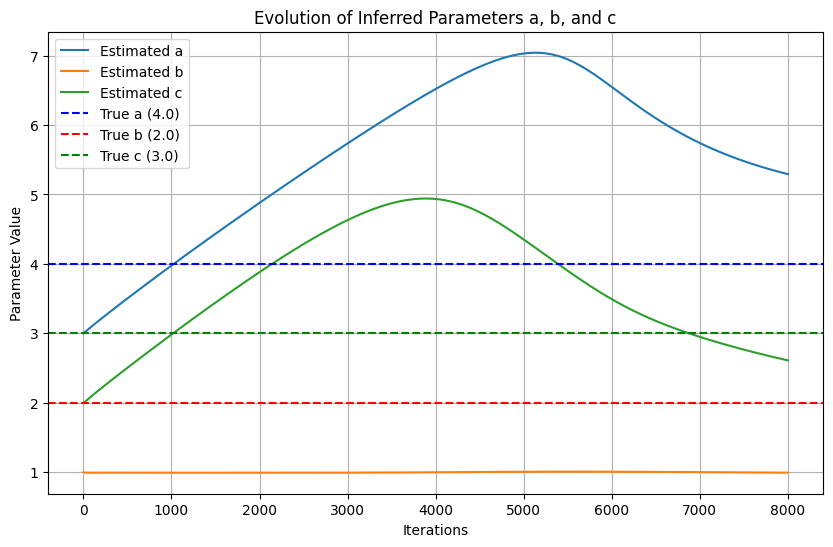

iter: 10000 loss: 0.0014975858 a: 4.907132 b: 0.9612232


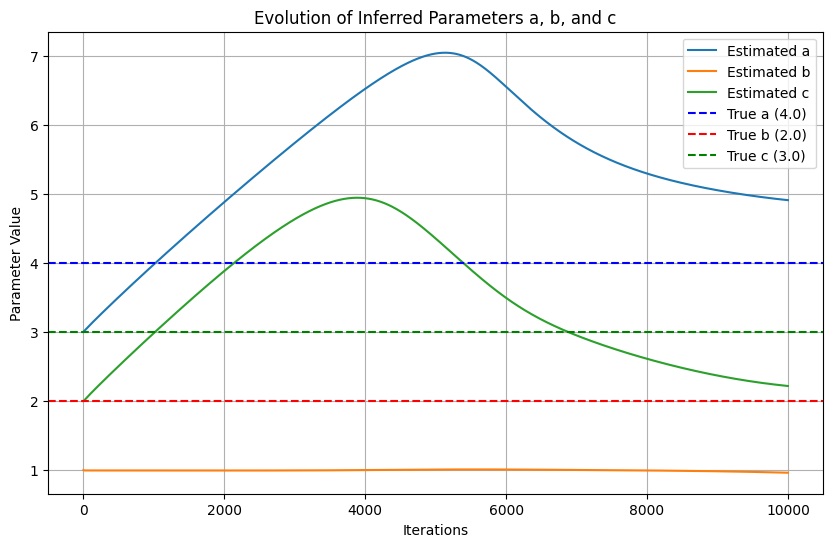

Inverse PINN training loop finished in 14.91 seconds


In [30]:
# Training loop

# Initialize lists to store values for plotting
iters_to_plot = []
a_values = []
b_values = []
c_values = []

start_time_inverse = time.time() # Record start time
for i in range(10001):

    loss, opt_state_inv, parameters_inv, theta_inv = inverse_step(
        opt_state_inv, optimiser_inv, parameters_inv, theta_inv, x_physics_batch, network)

    # Store values for plotting in every iteration
    iters_to_plot.append(i)
    a_values.append(theta_inv[0])
    b_values.append(theta_inv[1])
    c_values.append(theta_inv[2])

    if i % 2000 == 0:
        print("iter:", i, "loss:", loss,"a:", theta_inv[0],"b:", theta_inv[1])

        # Plot a, b, and c values (using all stored values up to this point)
        plt.figure(figsize=(10, 6))
        plt.plot(iters_to_plot, a_values, label='Estimated a')
        plt.plot(iters_to_plot, b_values, label='Estimated b')
        plt.plot(iters_to_plot, c_values, label='Estimated c')
        plt.xlabel('Iterations')
        plt.ylabel('Parameter Value')
        plt.title('Evolution of Inferred Parameters a, b, and c')
        plt.axhline(y=4.0, color='b', linestyle='--', label='True a (4.0)')
        plt.axhline(y=2.0, color='r', linestyle='--', label='True b (2.0)')
        plt.axhline(y=3.0, color='g', linestyle='--', label='True c (3.0)')
        plt.legend()
        plt.grid(True)
        plt.show()

end_time_inverse = time.time() # Record end time
print(f"Inverse PINN training loop finished in {end_time_inverse - start_time_inverse:.2f} seconds")